# Feature Selection - Lựa Chọn Đặc Trưng

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Thiết lập đường dẫn
BASE_DIR = Path.cwd().parent
INPUT_DIR = BASE_DIR / "outputs" / "data_split"
OUTPUT_DIR = BASE_DIR / "outputs" / "feature_selection"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Dữ Liệu

In [3]:
# Đọc dữ liệu từ data_split
train_df = pd.read_csv(INPUT_DIR / "train.csv")
val_df = pd.read_csv(INPUT_DIR / "val.csv")
test_df = pd.read_csv(INPUT_DIR / "test.csv")

print(f"📊 Train: {train_df.shape}")
print(f"📊 Val: {val_df.shape}")
print(f"📊 Test: {test_df.shape}")

📊 Train: (6862, 42)
📊 Val: (1557, 42)
📊 Test: (1992, 42)


## 3. Xác Định Features

In [4]:
# Xác định các cột features và ID
genre_cols = [col for col in train_df.columns if col.startswith("genre_") and col not in ["genre_count_scaled"]]
feature_cols = ["rating_scaled", "year_scaled", "genre_count_scaled"] + genre_cols
id_cols = ["user_idx", "movie_idx", "user_id", "movie_id", "movie_title", "rating"]

print(f"🎯 Số lượng features ban đầu: {len(feature_cols)}")
print(f"\n📋 Feature columns:")
print(feature_cols[:10], "...")

🎯 Số lượng features ban đầu: 28

📋 Feature columns:
['rating_scaled', 'year_scaled', 'genre_count_scaled', 'genre_count', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_comedy', 'genre_crime', 'genre_documentary'] ...


In [5]:
# Tách features
X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

print(f"✅ X_train shape: {X_train.shape}")
print(f"✅ X_val shape: {X_val.shape}")
print(f"✅ X_test shape: {X_test.shape}")

✅ X_train shape: (6862, 28)
✅ X_val shape: (1557, 28)
✅ X_test shape: (1992, 28)


## 4. Xây Dựng Pipeline

Pipeline bao gồm:
1. **StandardScaler**: Chuẩn hóa dữ liệu
2. **VarianceThreshold**: Loại bỏ features có phương sai thấp
3. **PCA**: Giảm chiều dữ liệu, giữ lại 95% phương sai

In [6]:
start_time = time.time()

# Xây dựng pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', VarianceThreshold(threshold=0.01)),
    ('pca', PCA(n_components=0.95, random_state=42))
])

print("✅ Pipeline đã được tạo")

✅ Pipeline đã được tạo


## 5. Fit Pipeline trên Train Set

In [7]:
# Fit pipeline CHỈ trên train set
pipeline.fit(X_train)

fit_time = time.time() - start_time
print(f"✅ Pipeline fitted trong {fit_time:.2f} giây")

✅ Pipeline fitted trong 0.04 giây


## 6. Transform Dữ Liệu

In [8]:
# Transform cả 3 tập
X_train_reduced = pipeline.transform(X_train)
X_val_reduced = pipeline.transform(X_val)
X_test_reduced = pipeline.transform(X_test)

print(f"📊 Kích thước sau khi giảm chiều:")
print(f"   Train: {X_train.shape} → {X_train_reduced.shape}")
print(f"   Val: {X_val.shape} → {X_val_reduced.shape}")
print(f"   Test: {X_test.shape} → {X_test_reduced.shape}")
print(f"\n📉 Giảm từ {X_train.shape[1]} xuống {X_train_reduced.shape[1]} features")
print(f"   Tỷ lệ giảm: {(1 - X_train_reduced.shape[1]/X_train.shape[1])*100:.1f}%")

📊 Kích thước sau khi giảm chiều:
   Train: (6862, 28) → (6862, 22)
   Val: (1557, 28) → (1557, 22)
   Test: (1992, 28) → (1992, 22)

📉 Giảm từ 28 xuống 22 features
   Tỷ lệ giảm: 21.4%


## 7. Phân Tích PCA

In [9]:
# Lấy thông tin PCA
pca_model = pipeline.named_steps['pca']
explained_variance = pca_model.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"📊 PCA Analysis:")
print(f"   Số components: {len(explained_variance)}")
print(f"   Tổng phương sai giữ lại: {cumulative_variance[-1]*100:.2f}%")
print(f"\n   Top 5 components:")
for i in range(min(5, len(explained_variance))):
    print(f"   PC{i+1}: {explained_variance[i]*100:.2f}% (Cumulative: {cumulative_variance[i]*100:.2f}%)")

📊 PCA Analysis:
   Số components: 22
   Tổng phương sai giữ lại: 95.72%

   Top 5 components:
   PC1: 13.07% (Cumulative: 13.07%)
   PC2: 8.12% (Cumulative: 21.19%)
   PC3: 6.53% (Cumulative: 27.72%)
   PC4: 6.34% (Cumulative: 34.06%)
   PC5: 4.90% (Cumulative: 38.96%)


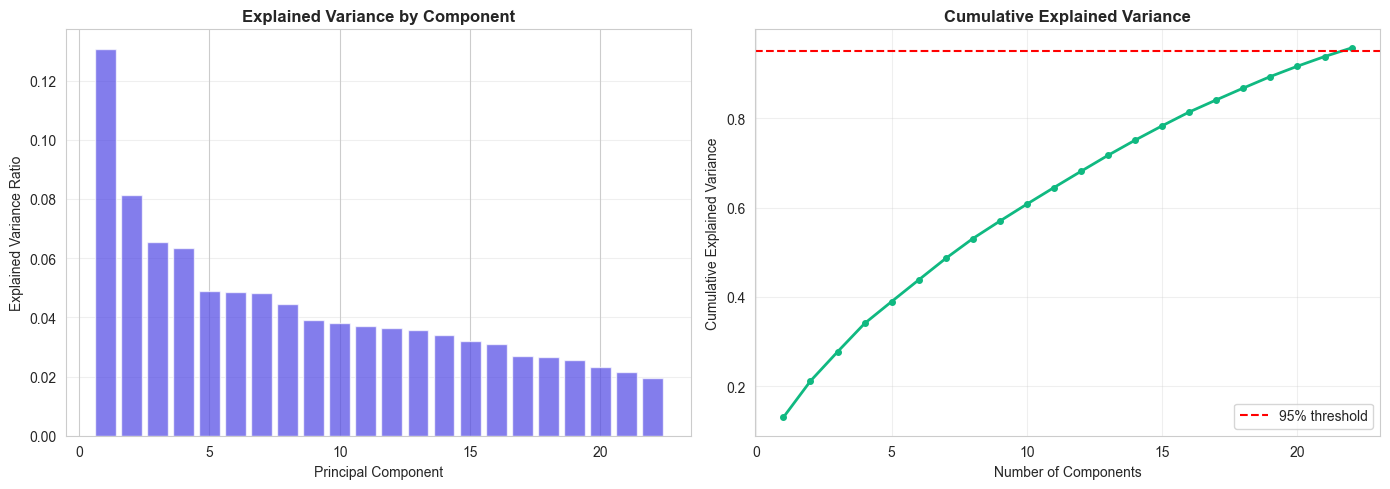

In [10]:
# Visualization: Explained Variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Individual variance
axes[0].bar(range(1, len(explained_variance)+1), explained_variance, color='#4f46e5', alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Explained Variance by Component', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Subplot 2: Cumulative variance
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 
             marker='o', color='#10b981', linewidth=2, markersize=4)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca_variance.png", dpi=300, bbox_inches='tight')
plt.show()

## 8. Tạo DataFrame Kết Quả

In [11]:
# Tạo tên cột cho PCA features
pca_cols = [f"pca_{i}" for i in range(X_train_reduced.shape[1])]

# Gộp với ID columns
train_reduced_df = pd.concat([
    train_df[id_cols].reset_index(drop=True), 
    pd.DataFrame(X_train_reduced, columns=pca_cols)
], axis=1)

val_reduced_df = pd.concat([
    val_df[id_cols].reset_index(drop=True), 
    pd.DataFrame(X_val_reduced, columns=pca_cols)
], axis=1)

test_reduced_df = pd.concat([
    test_df[id_cols].reset_index(drop=True), 
    pd.DataFrame(X_test_reduced, columns=pca_cols)
], axis=1)

print("✅ DataFrames đã được tạo")
train_reduced_df.head()

✅ DataFrames đã được tạo


,user_idx,movie_idx,user_id,movie_id,movie_title,rating,pca_0,pca_1,pca_2,pca_3,...,pca_12,pca_13,pca_14,pca_15,pca_16,pca_17,pca_18,pca_19,pca_20,pca_21
0,779,741,Sejian,1265609,War Machine,6.0,0.432847,2.274251,-0.254405,-0.045501,...,0.002155,-1.048619,-0.444658,-0.027073,0.321299,0.376514,-0.646183,-0.081520,-0.276528,0.550214
1,600,741,MovieGuys,1265609,War Machine,6.0,0.432847,2.274251,-0.254405,-0.045501,...,0.002155,-1.048619,-0.444658,-0.027073,0.321299,0.376514,-0.646183,-0.081520,-0.276528,0.550214
2,248,741,Dean,1265609,War Machine,9.0,0.543624,2.284708,-0.143674,-0.306084,...,0.332785,-0.951887,-0.243328,0.142538,0.308349,1.122984,-0.880236,-0.176126,-0.186522,0.553819
3,600,797,MovieGuys,1290821,Shelter,6.0,0.102790,1.637346,1.285074,0.539600,...,-0.008005,0.141342,0.226706,0.358616,-0.125376,-0.027351,-0.421946,0.182527,0.330696,-0.732560
4,473,2283,Kashifzia,799882,The Bluff,6.0,-0.901567,1.150824,-0.231464,-0.009824,...,-0.228185,-0.432714,-0.024924,0.646601,0.302484,0.637861,-0.004388,-0.466890,-1.099123,-0.469083


## 9. Lưu Kết Quả

In [12]:
# Lưu CSV
train_reduced_df.to_csv(OUTPUT_DIR / "train_features.csv", index=False)
val_reduced_df.to_csv(OUTPUT_DIR / "val_features.csv", index=False)
test_reduced_df.to_csv(OUTPUT_DIR / "test_features.csv", index=False)

print("✅ Đã lưu train_features.csv, val_features.csv, test_features.csv")

✅ Đã lưu train_features.csv, val_features.csv, test_features.csv


In [13]:
# Lưu Pipeline
joblib.dump(pipeline, OUTPUT_DIR / "preprocess_pipeline.pkl")
print("✅ Đã lưu preprocess_pipeline.pkl")

✅ Đã lưu preprocess_pipeline.pkl


In [14]:
# Lưu Selected Features
selected_features = {
    "original_features": feature_cols,
    "num_pca_components": len(pca_cols)
}

with open(OUTPUT_DIR / "selected_features.json", "w", encoding='utf-8') as f:
    json.dump(selected_features, f, indent=4, ensure_ascii=False)

print("✅ Đã lưu selected_features.json")

✅ Đã lưu selected_features.json


In [15]:
# Lưu Explained Variance
variance_info = {
    "total_variance_kept": float(np.sum(explained_variance)),
    "variance_per_component": explained_variance.tolist()
}

with open(OUTPUT_DIR / "explained_variance.json", "w", encoding='utf-8') as f:
    json.dump(variance_info, f, indent=4)

print("✅ Đã lưu explained_variance.json")

✅ Đã lưu explained_variance.json


In [16]:
# Lưu Log
log_data = {
    "fit_time_seconds": round(fit_time, 4),
    "dimensions_before": X_train.shape[1],
    "dimensions_after": X_train_reduced.shape[1],
    "reduction_ratio": round(1 - (X_train_reduced.shape[1] / X_train.shape[1]), 4)
}

with open(OUTPUT_DIR / "log.json", "w", encoding='utf-8') as f:
    json.dump(log_data, f, indent=4)

print("✅ Đã lưu log.json")

✅ Đã lưu log.json


## 10. Tổng Kết

Quá trình feature selection đã hoàn thành:

- **Phương pháp**: StandardScaler + VarianceThreshold + PCA
- **Giảm chiều**: Từ {X_train.shape[1]} xuống {X_train_reduced.shape[1]} features
- **Phương sai giữ lại**: {cumulative_variance[-1]*100:.2f}%
- **Outputs**: train_features.csv, val_features.csv, test_features.csv, preprocess_pipeline.pkl